In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
import yfinance as yf

# Fetching NVDA stock data
stock_ticker = 'NVDA'
data = yf.download(stock_ticker, period="5y")

# Ensure data is not empty
if data.empty:
    raise ValueError("Failed to fetch NVDA stock data. Check internet connection or ticker symbol.")

# Reset index to have 'Date' as a column
data.reset_index(inplace=True)

# Select relevant columns
data = data[['Date', 'Close', 'Volume']]

# Convert 'Date' column to datetime format and set as index
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Fetch VIX data
vix = yf.download("^VIX", start=data.index.min().strftime('%Y-%m-%d'), end=data.index.max().strftime('%Y-%m-%d'))[['Close']]

# Ensure VIX data is not empty
if vix.empty:
    raise ValueError("Failed to fetch VIX data. Check internet connection or ticker symbol.")

vix.rename(columns={'Close': 'Vix Price'}, inplace=True)

# Reindex VIX data to match NVDA data
vix = vix.reindex(data.index, method='ffill')

# Create features DataFrame
features = pd.DataFrame(index=data.index)
features['Close'] = data['Close']
features['Volume'] = data['Volume']
features['Vix Price'] = vix['Vix Price']

# Calculate percentage changes
features['Pct Change'] = features['Close'].pct_change() * 100

# Drop missing values
features.dropna(inplace=True)

# Ensure features DataFrame is not empty
if features.empty:
    raise ValueError("Features DataFrame is empty after preprocessing. Check data alignment.")

# Splitting the data
train_size = int(len(features) * 0.8)
train_data = features.iloc[:train_size]
test_data = features.iloc[train_size:]

# Save to CSV with index
train_data.to_csv("Training_Data.csv", index=True)
test_data.to_csv("Testing_Data.csv", index=True)

print("CSV files saved successfully!")


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

CSV files saved successfully!


In [27]:
### 4. Scaling and Preparing Data for LSTM
# Combine training and testing data for consistent scaling
combined_data = pd.concat([train_data, test_data])
sc = MinMaxScaler(feature_range=(0, 1))
combined_scaled = sc.fit_transform(combined_data[['Close', 'Vix Price', 'Pct Change']])

# Separate scaled data back into training and testing sets
scaled_train = combined_scaled[:len(train_data)]
scaled_test = combined_scaled[len(train_data):]

# Debugging scaling
print("Scaled Train Min:", np.min(scaled_train, axis=0))
print("Scaled Train Max:", np.max(scaled_train, axis=0))
print("Scaled Test Min:", np.min(scaled_test, axis=0))
print("Scaled Test Max:", np.max(scaled_test, axis=0))

# Preparing training data
X_train = []
y_train = []
for i in range(60, len(scaled_train)):
    X_train.append(scaled_train[i-60:i])
    y_train.append(scaled_train[i, 0])  # Predicting 'Close' price
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], X_train.shape[2]))

Scaled Train Min: [0.         0.00296485 0.        ]
Scaled Train Max: [0.44569678 1.         1.        ]
Scaled Test Min: [0.4328318  0.         0.03465331]
Scaled Test Max: [1.         0.37710008 0.81390856]


Epoch 1/100


/Users/alexanderdagher/.pyenv/versions/3.10.12/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0153 - val_loss: 0.0934
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 9.9615e-04 - val_loss: 0.0170
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 7.9405e-04 - val_loss: 0.0108
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 5.0380e-04 - val_loss: 0.0130
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 5.0601e-04 - val_loss: 0.0057
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 6.0563e-04 - val_loss: 0.0072
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 5.1888e-04 - val_loss: 0.0052
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 4.8367e-04 - val_loss: 0.0050
Epoch 9/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 4.6405e-04 - val_loss: 0.0060
Epoch 10/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 5.0859e-04 - val_loss: 0.0092
Epoch 11/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 4.7994e-04 - val_loss: 0.0048
Epoch 12/100
30/30 ━━━━━

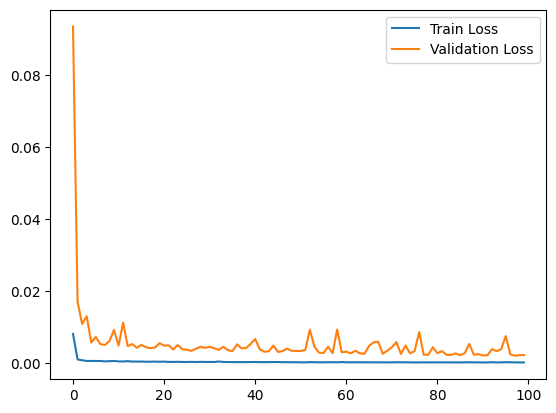

In [29]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
import numpy as np

# Scaling the features
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(features)

# Creating sequences for LSTM
def create_sequences(data, time_steps=50):
    X, y = [], []
    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i])  # Previous 'time_steps' data points
        y.append(data[i, 0])  # Predicting the Close price
    return np.array(X), np.array(y)

# Define time steps
time_steps = 50  # Using 50 days of past data to predict the next step

# Splitting scaled data into train/test
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

# Creating LSTM sequences
X_train, y_train = create_sequences(train_data, time_steps)
X_test, y_test = create_sequences(test_data, time_steps)

# Reshaping X for LSTM input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

# Building the LSTM Model
regressor = Sequential()
regressor.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50, return_sequences=False))
regressor.add(Dropout(0.2))
regressor.add(Dense(units=1))

# Compile the model
regressor.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = regressor.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))

# Plot Training Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()


In [37]:
### 6. Preparing Test Data and Making Predictions
# Preparing test data
y_test = test_data[:, 0][60:]  # Assuming 'Close' is the first column
X_test = []
for i in range(50, len(scaled_test)):  # Change 60 to 50
    X_test.append(scaled_test[i-50:i])
X_test = np.array(X_test)
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], X_test.shape[2]))

# Predicting stock prices
predicted_stock_price = regressor.predict(X_test, batch_size=32)
predicted_stock_price_expanded = np.zeros((predicted_stock_price.shape[0], scaled_train.shape[1]))
predicted_stock_price_expanded[:, 0] = predicted_stock_price.flatten()
predicted_stock_price = sc.inverse_transform(predicted_stock_price_expanded)[:, 0]

### Backtesting Logic
# Calculating trend accuracy
trend_real = np.sign(np.diff(y_test))  # Actual trends (1 for up, -1 for down, 0 for no change)
trend_predicted = np.sign(np.diff(predicted_stock_price))  # Predicted trends
trend_accuracy = np.mean(trend_real == trend_predicted) * 100

# Calculating price accuracy (Mean Absolute Percentage Error)
mape = np.mean(np.abs((y_test - predicted_stock_price) / y_test)) * 100

# Backtesting summary
overall_accuracy = 100 - mape  # Overall prediction accuracy
print("Trend Accuracy: {:.2f}%".format(trend_accuracy))
print("Mean Absolute Percentage Error (MAPE): {:.2f}%".format(mape))
print("Overall Accuracy Score: {:.2f}%".format(overall_accuracy))

# Saving backtesting results
backtest_results = pd.DataFrame({
    'Date': test_data['Date'].iloc[61:].values,  # Adjusted for diff()
    'Real Price': y_test[1:],
    'Predicted Price': predicted_stock_price[1:],
    'Real Trend': trend_real,
    'Predicted Trend': trend_predicted
})
backtest_results.to_csv("Backtesting_Results.csv", index=False)

### Future Prediction Logic (20 Days Ahead)
# Starting with the last 60 days of the test set
future_input = scaled_test[-60:]
future_predictions = []

for _ in range(20):
    # Reshape input to match LSTM expected shape
    future_input = future_input.reshape(1, future_input.shape[0], future_input.shape[1])
    future_pred = regressor.predict(future_input)

    # Append the prediction to the results
    future_predictions.append(future_pred[0, 0])

    # Update the input by appending the prediction and removing the oldest step
    next_step = np.zeros((1, scaled_train.shape[1]))
    next_step[0, 0] = future_pred[0, 0]
    future_input = np.vstack([future_input[0, 1:, :], next_step])

# Rescale predictions back to original range
future_predictions = sc.inverse_transform(
    np.pad(np.array(future_predictions).reshape(-1, 1), ((0, 0), (0, scaled_train.shape[1] - 1)), constant_values=0)
)[:, 0]

ValueError: Exception encountered when calling LSTMCell.call().

[1mDimensions must be equal, but are 3 and 4 for '{{node sequential_2_1/lstm_8_1/lstm_cell_1/MatMul}} = MatMul[T=DT_FLOAT, grad_a=false, grad_b=false, transpose_a=false, transpose_b=false](sequential_2_1/lstm_8_1/strided_slice_1, sequential_2_1/lstm_8_1/lstm_cell_1/Cast/ReadVariableOp)' with input shapes: [32,3], [4,200].[0m

Arguments received by LSTMCell.call():
  • inputs=tf.Tensor(shape=(32, 3), dtype=float32)
  • states=('tf.Tensor(shape=(32, 50), dtype=float32)', 'tf.Tensor(shape=(32, 50), dtype=float32)')
  • training=False

In [32]:
### 7. Visualizing Results and Saving Predictions
# Plotting results
plt.figure(figsize=(12, 6))
plt.plot(test_data['Date'].iloc[60:], y_test, color='red', label='Real Stock Price')
plt.plot(test_data['Date'].iloc[60:], predicted_stock_price, color='blue', label='Predicted Stock Price')
plt.title('Stock Price Prediction')
plt.xlabel('Time (Days)')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

# Saving predictions to CSV
output_test = pd.DataFrame({
    'Date': test_data['Date'].iloc[60:].values,
    'Real Price': y_test,
    'Predicted Price': predicted_stock_price.flatten()
})
output_test.to_csv("Fitted_Data_Output.csv", index=False)

# Saving future predictions to CSV
future_dates = pd.date_range(start=test_data['Date'].iloc[-1], periods=21, freq='B')[1:]
future_output = pd.DataFrame({
    'Date': future_dates,
    'Future Predicted Price': future_predictions
})
future_output.to_csv("Future_Predictions.csv", index=False)

# Plotting future predictions
plt.figure(figsize=(12, 6))
plt.plot(future_dates, future_predictions, color='green', label='Future Predicted Price')
plt.title('Future Stock Price Prediction (Next 20 Days)')
plt.xlabel('Future Dates')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

<Figure size 1200x600 with 0 Axes>